In [5]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
data = load_breast_cancer()

# Create feature DataFrame and target Series
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Number of instances:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget classes:")
print(data.target_names)

print("\nClass distribution:")
print(y.value_counts())

Number of instances: 569
Number of features: 30

Target classes:
['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training samples: 455
Testing samples: 114
Training data after scaling: (455, 30)
Testing data after scaling: (114, 30)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Create the five required models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Store results
results = []

# Train and evaluate every model
for name, model in models.items():

    # Logistic Regression and kNN use scaled data
    if name in ["Logistic Regression", "kNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Tree-based and Naive Bayes models use original data
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate required metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "ML Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Display rounded results
results_df.round(4)

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
2,kNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
3,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
4,Random Forest,0.9561,0.9937,0.9589,0.9722,0.9655,0.9054


In [ ]:
# Save the model comparison results
results_df.to_csv("model_results.csv", index=False)

print("Model results saved successfully.")
print("\nSaved results:")
display(results_df.round(4))

Model results saved successfully.

Saved results:


,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
2,kNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
3,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
4,Random Forest,0.9561,0.9937,0.9589,0.9722,0.9655,0.9054


In [10]:
# Store trained models and predictions for later use
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():

    if name in ["Logistic Regression", "kNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob

print("All five trained models and predictions have been stored.")

All five trained models and predictions have been stored.


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



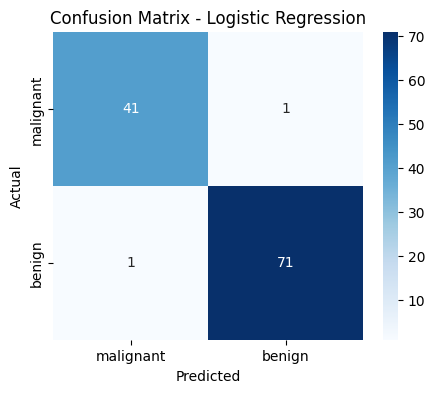

Decision Tree

Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



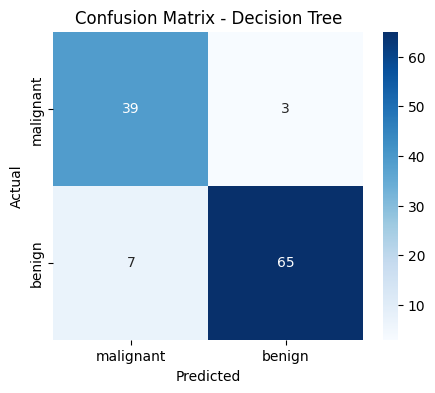

kNN

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



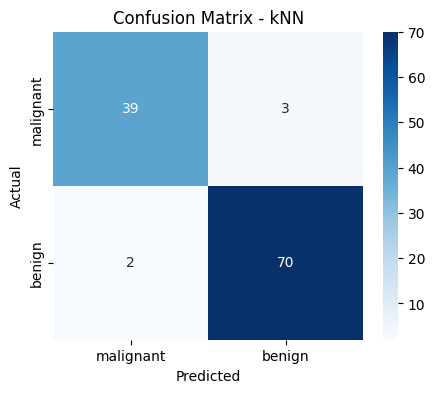

Naive Bayes

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



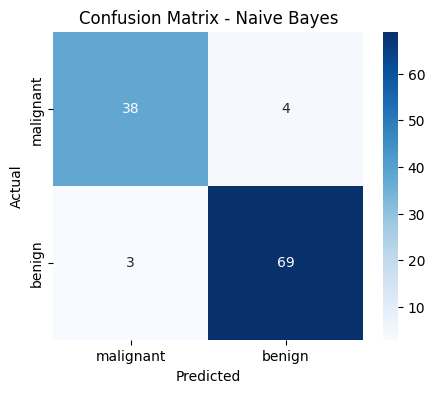

Random Forest

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



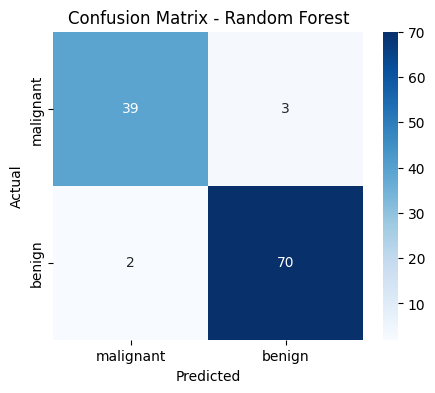

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name in models.keys():

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Get predictions
    y_pred = predictions[name]

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=data.target_names
        )
    )

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [17]:
import os

# Create project folders
os.makedirs("2025ac05727/model", exist_ok=True)

print("Project folder created!")
print(os.listdir("2025ac05727"))

Project folder created!
['model']


In [18]:
import joblib

# Save scaler
joblib.dump(
    scaler,
    "2025ac05727/model/scaler.pkl"
)

# Save trained models
for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    ) + ".pkl"

    joblib.dump(
        model,
        f"2025ac05727/model/{filename}"
    )

    print(f"Saved: {filename}")

print("\nAll models saved successfully.")

Saved: logistic_regression.pkl
Saved: decision_tree.pkl
Saved: knn.pkl
Saved: naive_bayes.pkl
Saved: random_forest.pkl

All models saved successfully.


In [ ]:
best_model_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best model based on F1 Score:")
display(best_model_row.to_frame().T)

Best model based on F1 Score:


,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.982456,0.99537,0.986111,0.986111,0.986111,0.962302


In [ ]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
).round(4)

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
2,kNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
4,Random Forest,0.9561,0.9937,0.9589,0.9722,0.9655,0.9054
3,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
1,Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174


In [19]:
# Create a test dataset containing features and the actual target
test_data = X_test.copy()
test_data["target"] = y_test.values

# Save test data
test_data.to_csv(
    "2025ac05727/test_data.csv",
    index=False
)

print("Test data saved successfully.")
print("Shape:", test_data.shape)

Test data saved successfully.
Shape: (114, 31)


In [20]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_df["Average Score"] = results_df[metric_columns].mean(axis=1)

print(
    results_df[
        ["ML Model", "Average Score"]
    ].sort_values(
        "Average Score",
        ascending=False
    ).round(4)
)

              ML Model  Average Score
0  Logistic Regression         0.9831
4        Random Forest         0.9587
2                  kNN         0.9562
3          Naive Bayes         0.9415
1        Decision Tree         0.9054


In [21]:
import os

# Create project folders
project_dir = "2025ac05727"
model_dir = os.path.join(project_dir, "model")

os.makedirs(model_dir, exist_ok=True)

print("Project structure created.")

Project structure created.


In [25]:
print(os.listdir(project_dir))

['test_data.csv', 'model']


In [23]:
# Combine test features and target
test_data = X_test.copy()
test_data["target"] = y_test.values

# Save test data
test_data_path = os.path.join(
    project_dir,
    "test_data.csv"
)

test_data.to_csv(
    test_data_path,
    index=False
)

print("Test data saved to:", test_data_path)
print("Test data shape:", test_data.shape)

Test data saved to: 2025ac05727/test_data.csv
Test data shape: (114, 31)


In [24]:
print(os.listdir(project_dir))

['test_data.csv', 'model']


In [26]:
results_path = os.path.join(
    project_dir,
    "model_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Model results saved to:", results_path)

Model results saved to: 2025ac05727/model_results.csv


In [27]:
import joblib
import os

# Save scaler
scaler_path = os.path.join(
    model_dir,
    "scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("Saved:", scaler_path)


# Save each trained model
for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    ) + ".pkl"

    filepath = os.path.join(
        model_dir,
        filename
    )

    joblib.dump(
        model,
        filepath
    )

    print("Saved:", filepath)

Saved: 2025ac05727/model/scaler.pkl
Saved: 2025ac05727/model/logistic_regression.pkl
Saved: 2025ac05727/model/decision_tree.pkl
Saved: 2025ac05727/model/knn.pkl
Saved: 2025ac05727/model/naive_bayes.pkl
Saved: 2025ac05727/model/random_forest.pkl


In [27]:
print("Project files:")
print(os.listdir(project_dir))

print("\nModel files:")
print(os.listdir(model_dir))

Project files:
['model_results.csv', 'test_data.csv', 'model']

Model files:
['knn.pkl', 'scaler.pkl', 'decision_tree.pkl', 'random_forest.pkl', 'naive_bayes.pkl', 'logistic_regression.pkl']


In [28]:
requirements = """streamlit
scikit-learn
pandas
numpy
matplotlib
seaborn
joblib
"""

requirements_path = os.path.join(
    project_dir,
    "requirements.txt"
)

with open(
    requirements_path,
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [29]:
with open(requirements_path, "r") as f:
    print(f.read())

streamlit
scikit-learn
pandas
numpy
matplotlib
seaborn
joblib



In [30]:
app_code = r'''
import streamlit as st
import pandas as pd
import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# PAGE CONFIGURATION
# ==========================================================

st.set_page_config(
    page_title="Breast Cancer Classification",
    page_icon="🧬",
    layout="wide"
)


# ==========================================================
# TITLE
# ==========================================================

st.title("Breast Cancer Classification")
st.write(
    "Machine Learning Assignment 2 - "
    "Classification Model Evaluation"
)

st.markdown(
    """
    This application evaluates five machine learning
    classification models using the uploaded test dataset.
    """
)


# ==========================================================
# MODEL FILE LOCATIONS
# ==========================================================

MODEL_FILES = {
    "Logistic Regression": "model/logistic_regression.pkl",
    "Decision Tree": "model/decision_tree.pkl",
    "kNN": "model/knn.pkl",
    "Naive Bayes": "model/naive_bayes.pkl",
    "Random Forest": "model/random_forest.pkl"
}


# ==========================================================
# UPLOAD TEST DATA
# ==========================================================

st.header("1. Upload Test Dataset")

uploaded_file = st.file_uploader(
    "Upload test_data.csv",
    type=["csv"]
)


if uploaded_file is None:

    st.info(
        "Please upload the test CSV file to begin evaluation."
    )

    st.stop()


# ==========================================================
# READ DATA
# ==========================================================

test_data = pd.read_csv(uploaded_file)

st.success("Test dataset uploaded successfully.")

st.subheader("Dataset Preview")

st.dataframe(
    test_data.head(),
    use_container_width=True
)


# ==========================================================
# CHECK TARGET COLUMN
# ==========================================================

if "target" not in test_data.columns:

    st.error(
        "The uploaded CSV must contain a 'target' column."
    )

    st.stop()


# ==========================================================
# SEPARATE FEATURES AND TARGET
# ==========================================================

X_test = test_data.drop(
    columns=["target"]
)

y_test = test_data["target"]


# ==========================================================
# MODEL SELECTION
# ==========================================================

st.header("2. Select Classification Model")

selected_model = st.selectbox(
    "Choose a model:",
    list(MODEL_FILES.keys())
)


# ==========================================================
# CHECK MODEL FILE
# ==========================================================

model_path = MODEL_FILES[selected_model]

if not os.path.exists(model_path):

    st.error(
        f"Model file not found: {model_path}"
    )

    st.stop()


# ==========================================================
# LOAD MODEL
# ==========================================================

model = joblib.load(model_path)


# ==========================================================
# PREPROCESS INPUT
# ==========================================================

if selected_model in [
    "Logistic Regression",
    "kNN"
]:

    scaler_path = "model/scaler.pkl"

    if not os.path.exists(scaler_path):

        st.error(
            "Scaler file not found."
        )

        st.stop()

    scaler = joblib.load(
        scaler_path
    )

    X_input = scaler.transform(
        X_test
    )

else:

    X_input = X_test


# ==========================================================
# MAKE PREDICTIONS
# ==========================================================

y_pred = model.predict(
    X_input
)

y_prob = model.predict_proba(
    X_input
)[:, 1]


# ==========================================================
# CALCULATE METRICS
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)


# ==========================================================
# DISPLAY METRICS
# ==========================================================

st.header("3. Evaluation Metrics")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Accuracy",
        f"{accuracy:.4f}"
    )

with col2:
    st.metric(
        "AUC",
        f"{auc:.4f}"
    )

with col3:
    st.metric(
        "Precision",
        f"{precision:.4f}"
    )


col4, col5, col6 = st.columns(3)

with col4:
    st.metric(
        "Recall",
        f"{recall:.4f}"
    )

with col5:
    st.metric(
        "F1 Score",
        f"{f1:.4f}"
    )

with col6:
    st.metric(
        "MCC",
        f"{mcc:.4f}"
    )


# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

st.header("4. Classification Report")

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

st.dataframe(
    report_df.round(4),
    use_container_width=True
)


# ==========================================================
# CONFUSION MATRIX
# ==========================================================

st.header("5. Confusion Matrix")

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(5, 4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    f"Confusion Matrix - {selected_model}"
)

st.pyplot(fig)


# ==========================================================
# MODEL COMPARISON
# ==========================================================

st.header("6. Model Comparison")

comparison_path = "model_results.csv"

if os.path.exists(comparison_path):

    comparison_df = pd.read_csv(
        comparison_path
    )

    st.dataframe(
        comparison_df.round(4),
        use_container_width=True
    )

else:

    st.warning(
        "model_results.csv was not found."
    )


# ==========================================================
# FOOTER
# ==========================================================

st.markdown("---")

st.write(
    "Machine Learning Assignment 2"
)
'''

app_path = os.path.join(
    project_dir,
    "app.py"
)

with open(
    app_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(app_code)

print("app.py created successfully.")
print(app_path)

app.py created successfully.
2025ac05727/app.py


In [32]:
with open(
    "2025ac05727/app.py",
    "r",
    encoding="utf-8"
) as f:
    print(f.read()[:2000])


import streamlit as st
import pandas as pd
import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# PAGE CONFIGURATION
# ==========================================================

st.set_page_config(
    page_title="Breast Cancer Classification",
    page_icon="🧬",
    layout="wide"
)


# ==========================================================
# TITLE
# ==========================================================

st.title("Breast Cancer Classification")
st.write(
    "Machine Learning Assignment 2 - "
    "Classification Model Evaluation"
)

st.markdown(
    """
    This application evaluates five machine learning
    classification models using the uploaded test dataset.
    """
)


# ==================

In [33]:
print("Dataset shape:", X.shape)

print("\nNumber of features:", X.shape[1])

print("\nFeature names:")
for feature in X.columns:
    print("-", feature)

print("\nTarget classes:")
print(data.target_names)

print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (569, 30)

Number of features: 30

Feature names:
- mean radius
- mean texture
- mean perimeter
- mean area
- mean smoothness
- mean compactness
- mean concavity
- mean concave points
- mean symmetry
- mean fractal dimension
- radius error
- texture error
- perimeter error
- area error
- smoothness error
- compactness error
- concavity error
- concave points error
- symmetry error
- fractal dimension error
- worst radius
- worst texture
- worst perimeter
- worst area
- worst smoothness
- worst compactness
- worst concavity
- worst concave points
- worst symmetry
- worst fractal dimension

Target classes:
['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [34]:
print(
    results_df.round(4).to_string(index=False)
)

           ML Model  Accuracy    AUC  Precision  Recall  F1 Score    MCC
Logistic Regression    0.9825 0.9954     0.9861  0.9861    0.9861 0.9623
      Decision Tree    0.9123 0.9157     0.9559  0.9028    0.9286 0.8174
                kNN    0.9561 0.9788     0.9589  0.9722    0.9655 0.9054
        Naive Bayes    0.9386 0.9878     0.9452  0.9583    0.9517 0.8676
      Random Forest    0.9561 0.9937     0.9589  0.9722    0.9655 0.9054


In [35]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_with_average = results_df.copy()

results_with_average["Average Score"] = (
    results_with_average[metric_columns].mean(axis=1)
)

print(
    results_with_average[
        ["ML Model", "Average Score"]
    ]
    .sort_values(
        "Average Score",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

           ML Model  Average Score
Logistic Regression         0.9831
      Random Forest         0.9587
                kNN         0.9562
        Naive Bayes         0.9415
      Decision Tree         0.9054


In [36]:
readme_template = """# Machine Learning Assignment 2

## 1. Problem Statement

This project implements and evaluates multiple machine learning
classification models on the Breast Cancer Wisconsin dataset.
The objective is to compare the performance of different
classification algorithms using multiple evaluation metrics.

## 2. Dataset Description

### Dataset Name

Breast Cancer Wisconsin Dataset

### Dataset Source

The dataset is provided through scikit-learn's breast cancer dataset.

### Number of Instances

569

### Number of Features

30

### Problem Type

Binary Classification

### Target Classes

The dataset contains two target classes.

## 3. GitHub Repository Link

To be added after GitHub repository creation.

## 4. Models Used

The following classification models were implemented:

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Gaussian Naive Bayes
5. Random Forest Classifier

### Evaluation Metrics

The following metrics were calculated:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

### Model Comparison

| ML Model | Accuracy | AUC | Precision | Recall | F1 Score | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | | | | | | |
| Decision Tree | | | | | | |
| kNN | | | | | | |
| Naive Bayes | | | | | | |
| Random Forest | | | | | | |

### Model Observations

#### Logistic Regression

Observation to be added based on experimental results.

#### Decision Tree

Observation to be added based on experimental results.

#### kNN

Observation to be added based on experimental results.

#### Naive Bayes

Observation to be added based on experimental results.

#### Random Forest

Observation to be added based on experimental results.

### Overall Winner

The overall winner will be identified based on the experimental evaluation results.

## 5. Streamlit Application

The application provides:

- Test CSV upload
- Model selection
- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- MCC
- Classification report
- Confusion matrix
- Model comparison

Live Streamlit link to be added after deployment.

## 6. Project Structure

ML_Assignment_2/

- app.py
- requirements.txt
- README.md
- test_data.csv
- model_results.csv
- model/
  - scaler.pkl
  - logistic_regression.pkl
  - decision_tree.pkl
  - knn.pkl
  - naive_bayes.pkl
  - random_forest.pkl
"""

readme_path = os.path.join(
    project_dir,
    "README.md"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_template)

print("README.md created.")

README.md created.


In [38]:
import os

for root, dirs, files in os.walk(
    "ML_Assignment_2"
):

    level = root.replace(
        "ML_Assignment_2",
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        indent +
        os.path.basename(root) +
        "/"
    )

    subindent = "    " * (level + 1)

    for file in files:
        print(
            subindent +
            file
        )